
# 🧪 TP — Analyse Textuelle en Python (Français)

## Objectifs pédagogiques

À la fin de ce TP, vous serez capable de :

- Prétraiter un corpus textuel en français  
- Explorer un corpus à l’aide d’un *wordcloud*  
- Extraire des thématiques avec le modèle LDA  
- Comparer des distributions thématiques  
- Appliquer une analyse de sentiment  
- Discuter de manière critique les limites des méthodes automatiques  

---



# 📘 Partie 1 — Chargement et exploration du corpus

## Consignes

1. Charger le corpus.
2. Examiner sa structure.
3. Identifier les variables disponibles.
4. Décrire brièvement le type de documents présents.


In [1]:

import pandas as pd

# Adapter le nom du fichier si nécessaire
df = pd.read_csv("corpus_fr_exemple.csv")

df = df.dropna(subset=["texte"]).reset_index(drop=True)

print("Taille du corpus :", len(df))
df.head()


Taille du corpus : 30


,date,source,titre,texte
0,2026-02-18,Le Quotidien Local,Grève des trains : trafic perturbé dans plusie...,Une grève reconductible des conducteurs a rédu...
1,2026-02-20,InfoTech,L’IA générative s’invite dans les services pub...,Plusieurs administrations testent des assistan...
2,2026-02-21,ÉcoMatin,"Inflation : la hausse des prix ralentit, mais ...",Les derniers indicateurs montrent un ralentiss...
3,2026-02-22,Sport & Ville,Le club de la capitale se qualifie au bout du ...,"Dans un match très disputé, l’équipe s’est imp..."
4,2026-02-23,Planète,Sécheresse : des restrictions d’eau prolongées...,Plusieurs départements envisagent de prolonger...



# 🧹 Partie 2 — Prétraitement du texte (français)

Nous allons :
- Mettre en minuscules
- Supprimer les mots vides
- Lemmatiser
- Conserver uniquement les mots alphabétiques

## Questions

1. Pourquoi retire-t-on les stopwords ?  
2. Pourquoi utiliser les lemmes plutôt que les mots bruts ?  
3. Quelle information risque-t-on de perdre ?  


In [2]:

import re
import spacy

nlp = spacy.load("fr_core_news_sm")

def preprocess_fr(text):
    text = re.sub(r"\s+", " ", str(text))
    doc = nlp(text.lower())
    
    tokens = [
        t.lemma_
        for t in doc
        if t.is_alpha and not t.is_stop and len(t) > 2
    ]
    
    return " ".join(tokens)

df["texte_clean"] = df["texte"].apply(preprocess_fr)

df[["texte", "texte_clean"]].head()


,texte,texte_clean
0,Une grève reconductible des conducteurs a rédu...,grève reconductible conducteur réduire circula...
1,Plusieurs administrations testent des assistan...,administration tester assistant écriture résum...
2,Les derniers indicateurs montrent un ralentiss...,dernier indicateur montrer ralentissement infl...
3,"Dans un match très disputé, l’équipe s’est imp...",match disputé équipe imposer tir but entraîneu...
4,Plusieurs départements envisagent de prolonger...,département envisager prolonger restriction ar...



# ☁️ Partie 3 — Wordcloud

Le wordcloud permet une exploration rapide du vocabulaire dominant.

## Questions d’analyse

1. Quels mots dominent ?  
2. Représentent-ils réellement des thèmes ?  
3. Quelles sont les limites de cette méthode ?  


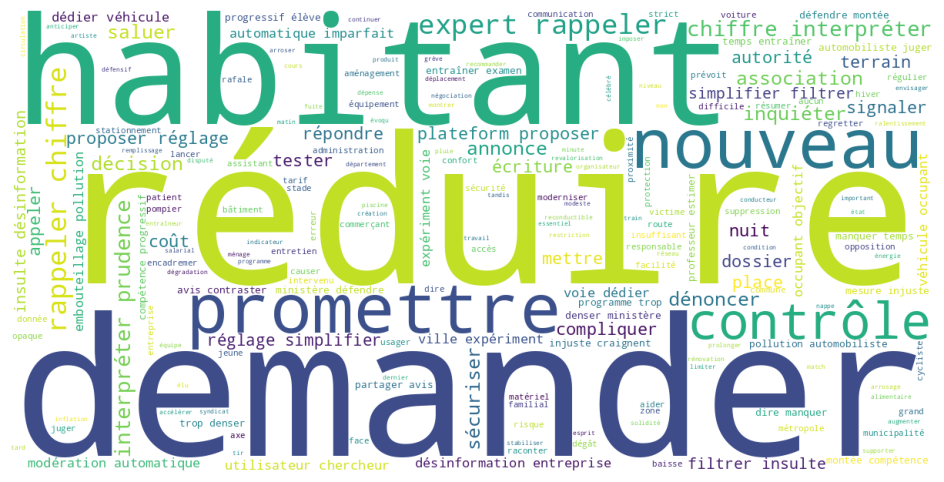

In [3]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["texte_clean"])

wc = WordCloud(width=1200, height=600, background_color="white")
wc.generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()



# 🧠 Partie 4 — Modélisation thématique (LDA)

Nous allons :
- Construire une matrice document-terme
- Appliquer un modèle LDA
- Interpréter les thèmes obtenus

## Questions

1. Que signifient les paramètres `min_df` et `max_df` ?  
2. Comment interpréter un thème ?  
3. Le nombre de thèmes choisi est-il pertinent ?  


In [4]:

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_df=0.95, min_df=2)
X = vectorizer.fit_transform(df["texte_clean"])

X.shape


(30, 137)

In [5]:

from sklearn.decomposition import LatentDirichletAllocation

K = 5
lda = LatentDirichletAllocation(n_components=K, random_state=42)
lda.fit(X)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [16]:

import numpy as np

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = np.array(feature_names)[topic.argsort()[-10:]]
    print(f"\nThème {topic_idx+1} :")
    print(", ".join(top_words))

vocab = vectorizer.get_feature_names_out()
def top_words(topic_weights, n=10):
    return [vocab[i] for i in topic_weights.argsort()[:-n-1:-1]]


topics = [np.array(feature_names)[lda.components_[k].argsort()[-10:]] for k in range(K)]

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (1811683156.py, line 15)


## Interprétation

Pour chaque thème :
- Proposez un titre
- Décrivez le sujet représenté
- Discutez des éventuels chevauchements


In [7]:

doc_topic = lda.transform(X)

df["topic_id"] = doc_topic.argmax(axis=1) + 1
df["topic_score"] = doc_topic.max(axis=1)

df[["topic_id", "topic_score"]].head()


,topic_id,topic_score
0,1,0.838064
1,4,0.963546
2,1,0.507315
3,2,0.732962
4,5,0.731567


In [8]:

pivot = pd.crosstab(df["source"], df["topic_id"], normalize="index")
pivot


topic_id,1,2,3,4,5
source,,,,,
Culture Pop,1.000000,0.000000,0.0,0.000000,0.0
InfoTech,0.333333,0.000000,0.0,0.666667,0.0
Le Quotidien Local,0.333333,0.666667,0.0,0.000000,0.0
Mobilités,0.000000,0.400000,0.0,0.600000,0.0
Numérique,0.000000,0.000000,0.0,0.000000,1.0
Planète,0.500000,0.000000,0.0,0.000000,0.5
Santé & Société,0.000000,0.500000,0.0,0.000000,0.5
Sport & Ville,0.666667,0.333333,0.0,0.000000,0.0
ÉcoMatin,0.500000,0.000000,0.0,0.000000,0.5



# 😊 Partie 5 — Analyse de sentiment

Nous appliquons un modèle pré-entraîné sur les titres.

## Questions

1. Le sentiment est-il plus visible dans les titres ou les textes complets ?  
2. Certains médias utilisent-ils un ton plus négatif ?  
3. Peut-on faire confiance totalement à ces modèles ?  


In [9]:
from transformers import pipeline
import os

os.environ['HTTP_PROXY'] = 'http://cache.univ-st-etienne.fr:3128/'
os.environ['HTTPS_PROXY'] = 'http://cache.univ-st-etienne.fr:3128/'

import numpy as np
import pandas as pd
from transformers import pipeline

sentiment = pipeline(
    "text-classification",
    model="tabularisai/multilingual-sentiment-analysis",
    # device=0,  # décommente si tu as un GPU CUDA
)

# mapping des labels HF -> poids
# (les repos HF varient parfois: "LABEL_0" vs "Very Negative", etc.)
WEIGHTS = {
    "VERY NEGATIVE": -2,
    "NEGATIVE": -1,
    "NEUTRAL": 0,
    "POSITIVE": 1,
    "VERY POSITIVE": 2,
    "LABEL_0": -2,
    "LABEL_1": -1,
    "LABEL_2": 0,
    "LABEL_3": 1,
    "LABEL_4": 2,
}

def polarity_hf_batch(texts, max_length=512, batch_size=32, neutral_threshold=0.15):
    """
    Retourne 2 listes: scores [-1,+1] et labels FR.
    neutral_threshold: zone morte autour de 0 pour éviter de sur-classer.
    """
    # clean + placeholders
    clean = []
    idx_map = []
    scores = [0.0] * len(texts)
    labels = ["neutre"] * len(texts)

    for i, t in enumerate(texts):
        if isinstance(t, str) and t.strip():
            clean.append(t)
            idx_map.append(i)

    if not clean:
        return scores, labels

    # IMPORTANT: on veut toutes les classes pour calculer un score attendu
    # top_k=None => renvoie toutes les classes (Transformers récents)
    outs = sentiment(
        clean,
        truncation=True,
        max_length=max_length,
        batch_size=batch_size,
        top_k=None,
    )

    for out, original_i in zip(outs, idx_map):
        # out = liste de dicts [{label, score}, ...] (toutes les classes)
        exp = 0.0
        total = 0.0
        for d in out:
            w = WEIGHTS.get(d["label"].upper())
            if w is None:
                continue
            p = float(d["score"])
            exp += w * p
            total += p

        # score attendu normalisé -> [-1, +1]
        s = (exp / total) / 2.0 if total > 0 else 0.0

        if s > neutral_threshold:
            lab = "positif"
        elif s < -neutral_threshold:
            lab = "négatif"
        else:
            lab = "neutre"

        scores[original_i] = float(s)
        labels[original_i] = lab

    return scores, labels


# --- Application DF rapide (batch) ---
texts = df["texte_clean"].tolist()
sc, lab = polarity_hf_batch(texts, batch_size=32)

df["polarity_score"] = sc
df["polarity_label"] = lab

df[["titre", "polarity_score", "polarity_label"]].head(3)

C:\Users\ga102583\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu


,titre,polarity_score,polarity_label
0,Grève des trains : trafic perturbé dans plusie...,-0.410568,négatif
1,L’IA générative s’invite dans les services pub...,-0.003449,neutre
2,"Inflation : la hausse des prix ralentit, mais ...",-0.094491,neutre


## 6) Bonus : LLM via API **Mistral** (optionnel)

Objectifs pédagogiques :
- voir qu’un LLM peut servir de **stagiaire annotateur** (titres de topics, tonalité, résumé…)
- comprendre les limites (coût, quotas, biais, hallucinations)

### Prérequis
1. Créer une clé API Mistral (AI Studio / plateforme Mistral)
2. Dans Colab : **Paramètres / Secrets** (ou variables d’environnement) → ajouter `MISTRAL_API_KEY`
3. Relancer le runtime si besoin.

Docs officielles : endpoint “chat” et quickstart Mistral. (Voir docs.mistral.ai)


In [10]:
from transformers import pipeline
import os

os.environ['HTTP_PROXY'] = 'http://cache.univ-st-etienne.fr:3128/'
os.environ['HTTPS_PROXY'] = 'http://cache.univ-st-etienne.fr:3128/'
sentiment = pipeline("sentiment-analysis", model="tabularisai/multilingual-sentiment-analysis")

def polarity_hf(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0, "neutre"
    out = sentiment(text[:512])[0]  # tronque pour éviter les textes trop longs
    # out: {'label': 'POSITIVE'/'NEGATIVE', 'score': 0.x}
    label = "positif" if out["label"].upper().startswith("POS") else "négatif"
    score = out["score"] if label == "positif" else -out["score"]
    return score, label

df[["polarity_score", "polarity_label"]] = df["texte_clean"].apply(
    lambda x: pd.Series(polarity_hf(x))
)

df[["titre", "polarity_score", "polarity_label"]].head(3)

Device set to use cpu


,titre,polarity_score,polarity_label
0,Grève des trains : trafic perturbé dans plusie...,-0.379372,négatif
1,L’IA générative s’invite dans les services pub...,-0.935206,négatif
2,"Inflation : la hausse des prix ralentit, mais ...",-0.703804,négatif


In [11]:
import os, requests, json, time

MISTRAL_API_KEY = "caowyfxmdKEXyW8EN2Y9LtvtcdCw1hvh"
if not MISTRAL_API_KEY:
    print("⚠️ Pas de clé Mistral trouvée. Ajoute MISTRAL_API_KEY dans les secrets Colab pour activer le bonus.")
else:
    print("✅ Clé Mistral détectée (bonus activable).")

✅ Clé Mistral détectée (bonus activable).


### 6.a) Fonction utilitaire : appeler Mistral Chat Completions

On utilise l’endpoint standard : `https://api.mistral.ai/v1/chat/completions`.

> Astuce cours : limiter la taille des entrées, et ne pas appeler le LLM sur 200 textes d’un coup.

In [12]:
def mistral_chat(messages, model="mistral-small-latest", max_tokens=150, temperature=0.2):
    if not MISTRAL_API_KEY:
        raise RuntimeError("MISTRAL_API_KEY manquante.")
    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {MISTRAL_API_KEY}", "Content-Type": "application/json"}
    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }
    r = requests.post(url, headers=headers, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data["choices"][0]["message"]["content"].strip()

# Test rapide (décommente si clé présente)
# print(mistral_chat([{"role":"user","content":"Donne 3 synonymes de 'rapide' en français."}]))

### 6.b) Faire titrer automatiquement les topics LDA

On fournit au LLM :
- la liste des mots du topic
- une consigne de titre court

Le LLM renvoie un libellé lisible (“Mobilités urbaines”, “Santé publique”, etc.)


In [13]:
def label_topic(words):
    prompt = (
        "Tu es analyste médias. Donne un titre court (3 à 6 mots) "
        "pour un thème représenté par ces mots :\n"
        f"{', '.join(words)}\n\n"
        "Réponds uniquement par le titre."
    )
    return mistral_chat([{"role":"user","content": prompt}], max_tokens=30, temperature=0.1)

topic_labels = []
if MISTRAL_API_KEY:
    for words in topics:
        topic_labels.append(label_topic(words))
        time.sleep(0.5)  # petit délai pour éviter des limites de débit
    for i, (lab, words) in enumerate(zip(topic_labels, topics), start=1):
        print(f"Topic {i} → {lab} | mots: {', '.join(words)}")
else:
    print("Clé absente → saute cette cellule.")

NameError: name 'topics' is not defined

### 6.c) Classer la “tonalité” de titres (positif / négatif / neutre)

Ici on fait très simple :
- on envoie uniquement le **titre** (court)
- on demande une sortie **JSON** pour pouvoir compter facilement

> Important : ce n’est pas “la vérité”. C’est une estimation, sensible au prompt, au modèle, au contexte.


In [ ]:
import json

def sentiment_title(title):
    prompt = f'''
Classe la tonalité de ce titre de presse en français :
"{title}"

Réponds en JSON strict, sans texte autour, avec les clés:
- label: "positif" | "negatif" | "neutre"
- justification: une phrase courte
'''.strip()
    out = mistral_chat([{"role":"user","content": prompt}], max_tokens=120, temperature=0.0)
    return json.loads("\n".join(out.split("\n")[1:-1]))

if MISTRAL_API_KEY:
    sample = df["titre"].head(8).tolist()
    results = [sentiment_title(t) for t in sample]
    for t, r in zip(sample, results):
        print("-", t)
        print(" ", r["label"], "|", r["justification"])
else:
    print("Clé absente → saute cette cellule.")